In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [16]:
df = pd.read_csv('Heart_Disease_Prediction.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

print("\nDataset Overview:")
print(df.head(10))


Dataset Shape: (270, 14)
Number of Samples: 270
Number of Features: 14

Dataset Overview:
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   
5   65    1                4  120          177             0            0   
6   56    1                3  130          256             1            2   
7   59    1                4  110          239             0            2   
8   60    1                4  140          293             0            2   
9   63    0                4  150          407             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0  

In [17]:
print("\nDataset Information:")
print(df.info())

print("\nTarget Variable Distribution:")
print(df['Heart Disease'].value_counts())

print("\nChecking for Missing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: f

## Data Preprocessing

In [18]:
# Encode the target variable
le = LabelEncoder()
df['Heart Disease'] = le.fit_transform(df['Heart Disease'])

print("\nTarget Variable Encoding:")
print("Presence -> 1, Absence -> 0")

# Separate features and target
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

# Feature Scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed (StandardScaler)")


Target Variable Encoding:
Presence -> 1, Absence -> 0

Feature Matrix Shape: (270, 13)
Target Vector Shape: (270,)

Training Set: 216 samples
Test Set: 54 samples

Feature scaling completed (StandardScaler)


## Tree-Based Models

In [19]:
print("\n[Model 1] Decision Tree Classifier")

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"Predictions generated on test set")


[Model 1] Decision Tree Classifier
Predictions generated on test set


In [20]:
print("\nRandom Forest Classifier")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    min_samples_split=10
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Predictions generated on test set")


Random Forest Classifier
Predictions generated on test set


In [21]:
# Gradient Boosted Trees Classifier
print("\nGradient Boosted Trees Classifier")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

print(f"Predictions generated on test set")


Gradient Boosted Trees Classifier
Predictions generated on test set


## K-Nearest Neighbors (KNN) Model

In [22]:
# Test multiple values of k (k = 1 to 20)
k_values = range(1, 21)
knn_scores = {
    'k': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

print("\nTesting k values from 1 to 20...")

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    knn_pred = knn_model.predict(X_test_scaled)

    acc = accuracy_score(y_test, knn_pred)
    prec = precision_score(y_test, knn_pred)
    rec = recall_score(y_test, knn_pred)
    f1 = f1_score(y_test, knn_pred)

    knn_scores['k'].append(k)
    knn_scores['accuracy'].append(acc)
    knn_scores['precision'].append(prec)
    knn_scores['recall'].append(rec)
    knn_scores['f1'].append(f1)

    print(f"k={k:2d} | Accuracy: {acc:.4f} | Precision: {prec:.4f} | "
          f"Recall: {rec:.4f} | F1: {f1:.4f}")

# Identify optimal k value
optimal_k_idx = np.argmax(knn_scores['f1'])
optimal_k = knn_scores['k'][optimal_k_idx]

print(f"\n{'='*80}")
print(f"OPTIMAL K VALUE: {optimal_k} (based on highest F1-score)")
print(f"{'='*80}")

# Train final KNN model with optimal k
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train_scaled, y_train)
knn_final_pred = knn_final.predict(X_test_scaled)

knn_accuracy = knn_scores['accuracy'][optimal_k_idx]
knn_precision = knn_scores['precision'][optimal_k_idx]
knn_recall = knn_scores['recall'][optimal_k_idx]
knn_f1 = knn_scores['f1'][optimal_k_idx]


Testing k values from 1 to 20...
k= 1 | Accuracy: 0.8148 | Precision: 0.7692 | Recall: 0.8333 | F1: 0.8000
k= 2 | Accuracy: 0.8148 | Precision: 0.8500 | Recall: 0.7083 | F1: 0.7727
k= 3 | Accuracy: 0.8148 | Precision: 0.7500 | Recall: 0.8750 | F1: 0.8077
k= 4 | Accuracy: 0.8333 | Precision: 0.8000 | Recall: 0.8333 | F1: 0.8163
k= 5 | Accuracy: 0.7963 | Precision: 0.7241 | Recall: 0.8750 | F1: 0.7925
k= 6 | Accuracy: 0.7778 | Precision: 0.7500 | Recall: 0.7500 | F1: 0.7500
k= 7 | Accuracy: 0.7963 | Precision: 0.7241 | Recall: 0.8750 | F1: 0.7925
k= 8 | Accuracy: 0.8148 | Precision: 0.7692 | Recall: 0.8333 | F1: 0.8000
k= 9 | Accuracy: 0.8333 | Precision: 0.7778 | Recall: 0.8750 | F1: 0.8235
k=10 | Accuracy: 0.8333 | Precision: 0.8000 | Recall: 0.8333 | F1: 0.8163
k=11 | Accuracy: 0.8519 | Precision: 0.8077 | Recall: 0.8750 | F1: 0.8400
k=12 | Accuracy: 0.8333 | Precision: 0.8261 | Recall: 0.7917 | F1: 0.8085
k=13 | Accuracy: 0.8148 | Precision: 0.7500 | Recall: 0.8750 | F1: 0.8077
k=14

### Plot KNN Performance vs K-values


Plotting KNN Performance vs K-values...


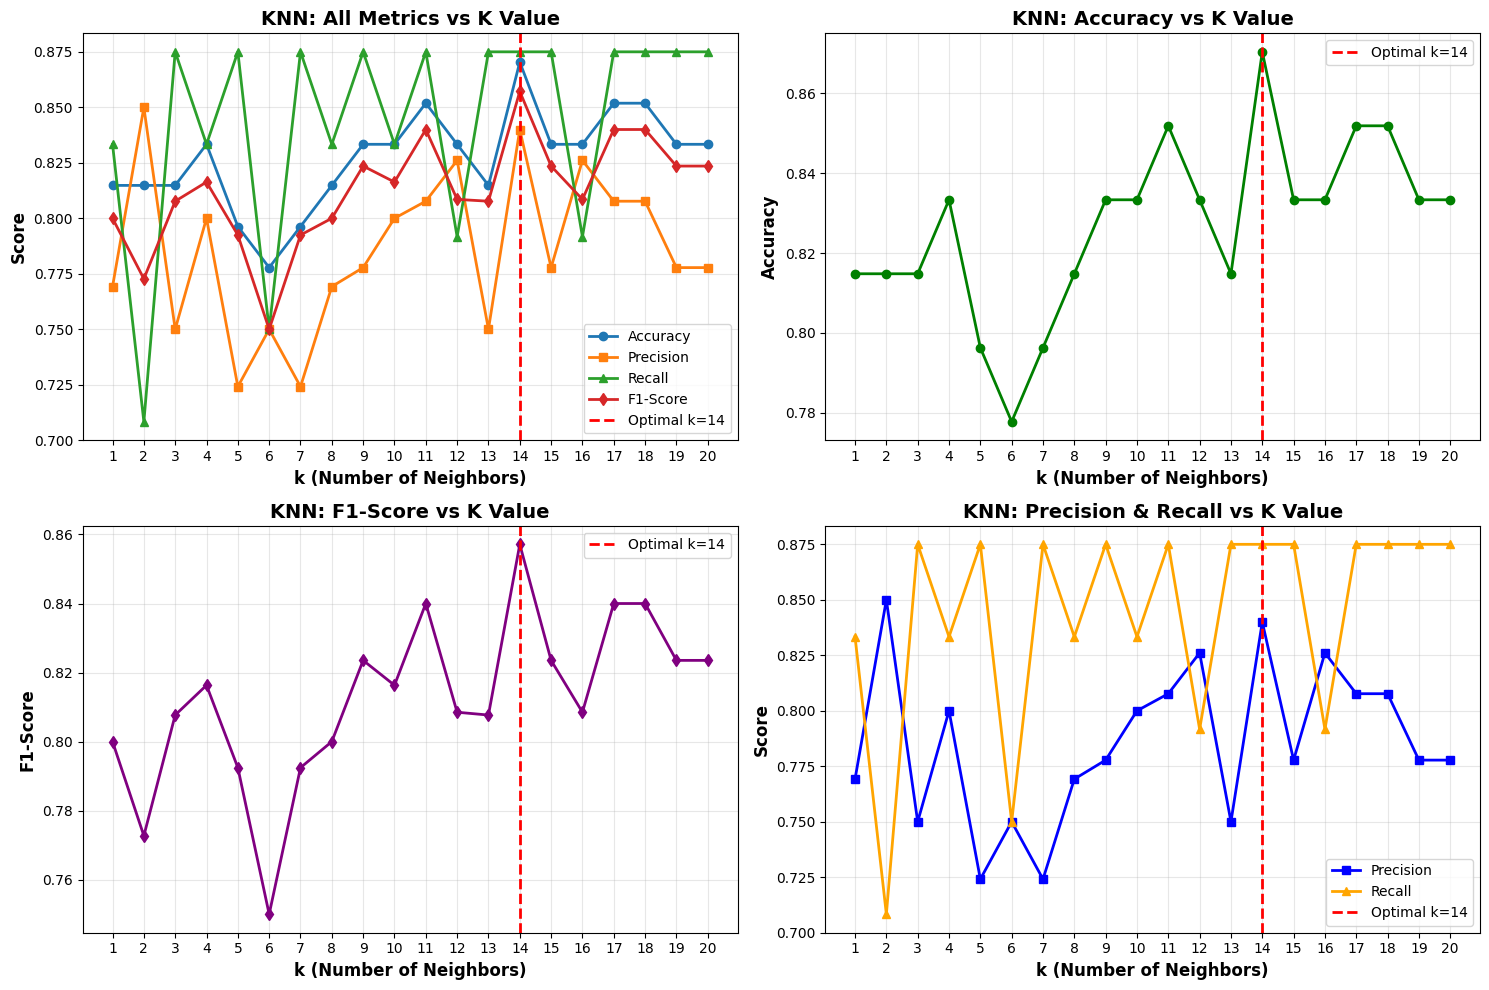

Plot saved as 'knn_performance_vs_k.png'


In [23]:
print("\nPlotting KNN Performance vs K-values...")

plt.figure(figsize=(15, 10))

# Plot 1: All metrics vs k
plt.subplot(2, 2, 1)
plt.plot(knn_scores['k'], knn_scores['accuracy'], marker='o', label='Accuracy', linewidth=2)
plt.plot(knn_scores['k'], knn_scores['precision'], marker='s', label='Precision', linewidth=2)
plt.plot(knn_scores['k'], knn_scores['recall'], marker='^', label='Recall', linewidth=2)
plt.plot(knn_scores['k'], knn_scores['f1'], marker='d', label='F1-Score', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('KNN: All Metrics vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))

# Plot 2: Accuracy vs k
plt.subplot(2, 2, 2)
plt.plot(knn_scores['k'], knn_scores['accuracy'], marker='o', color='green', linewidth=2, markersize=6)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('KNN: Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))

# Plot 3: F1-Score vs k
plt.subplot(2, 2, 3)
plt.plot(knn_scores['k'], knn_scores['f1'], marker='d', color='purple', linewidth=2, markersize=6)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('KNN: F1-Score vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))

# Plot 4: Precision & Recall vs k
plt.subplot(2, 2, 4)
plt.plot(knn_scores['k'], knn_scores['precision'], marker='s',
         label='Precision', color='blue', linewidth=2, markersize=6)
plt.plot(knn_scores['k'], knn_scores['recall'], marker='^',
         label='Recall', color='orange', linewidth=2, markersize=6)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('KNN: Precision & Recall vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))

plt.tight_layout()
plt.savefig('knn_performance_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'knn_performance_vs_k.png'")

## Evaluation Metrics

In [24]:
# Create results summary table
summary_data = {
    'Model': [
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        f'KNN (k={optimal_k})'
    ],
    'Accuracy': [dt_accuracy, rf_accuracy, gb_accuracy, knn_accuracy],
    'Precision': [dt_precision, rf_precision, gb_precision, knn_precision],
    'Recall': [dt_recall, rf_recall, gb_recall, knn_recall],
    'F1-Score': [dt_f1, rf_f1, gb_f1, knn_f1]
}

results_df = pd.DataFrame(summary_data)
results_df = results_df.set_index('Model')

# Display results table
print("EVALUATION RESULTS TABLE")
print(results_df.to_string())

# Best performing models
print("BEST PERFORMING MODELS BY METRIC")

print(f"Highest Accuracy:  {results_df['Accuracy'].idxmax():25s} = {results_df['Accuracy'].max():.4f}")
print(f"Highest Precision: {results_df['Precision'].idxmax():25s} = {results_df['Precision'].max():.4f}")
print(f"Highest Recall:    {results_df['Recall'].idxmax():25s} = {results_df['Recall'].max():.4f}")
print(f"Highest F1-Score:  {results_df['F1-Score'].idxmax():25s} = {results_df['F1-Score'].max():.4f}")

EVALUATION RESULTS TABLE
                   Accuracy  Precision    Recall  F1-Score
Model                                                     
Decision Tree      0.777778   0.730769  0.791667  0.760000
Random Forest      0.833333   0.800000  0.833333  0.816327
Gradient Boosting  0.814815   0.750000  0.875000  0.807692
KNN (k=14)         0.870370   0.840000  0.875000  0.857143
BEST PERFORMING MODELS BY METRIC
Highest Accuracy:  KNN (k=14)                = 0.8704
Highest Precision: KNN (k=14)                = 0.8400
Highest Recall:    Gradient Boosting         = 0.8750
Highest F1-Score:  KNN (k=14)                = 0.8571


## Additional Visualizations


Generating Model Comparison Visualizations...


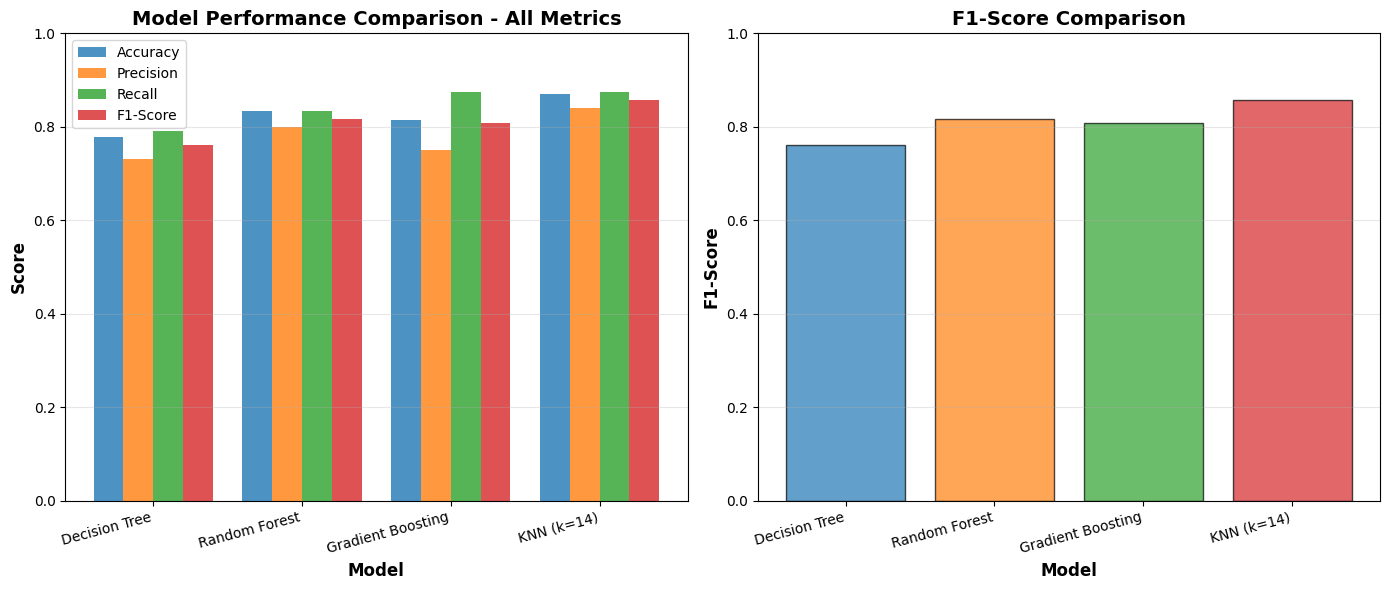

Plot saved as 'model_comparison.png'


In [25]:
print("\nGenerating Model Comparison Visualizations...")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
x = np.arange(len(results_df.index))
width = 0.2
plt.bar(x - 1.5*width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', alpha=0.8)
plt.bar(x + 0.5*width, results_df['Recall'], width, label='Recall', alpha=0.8)
plt.bar(x + 1.5*width, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')
plt.xticks(x, results_df.index, rotation=15, ha='right')
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plt.bar(results_df.index, results_df['F1-Score'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('F1-Score Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'model_comparison.png'")


Generating Confusion Matrices...


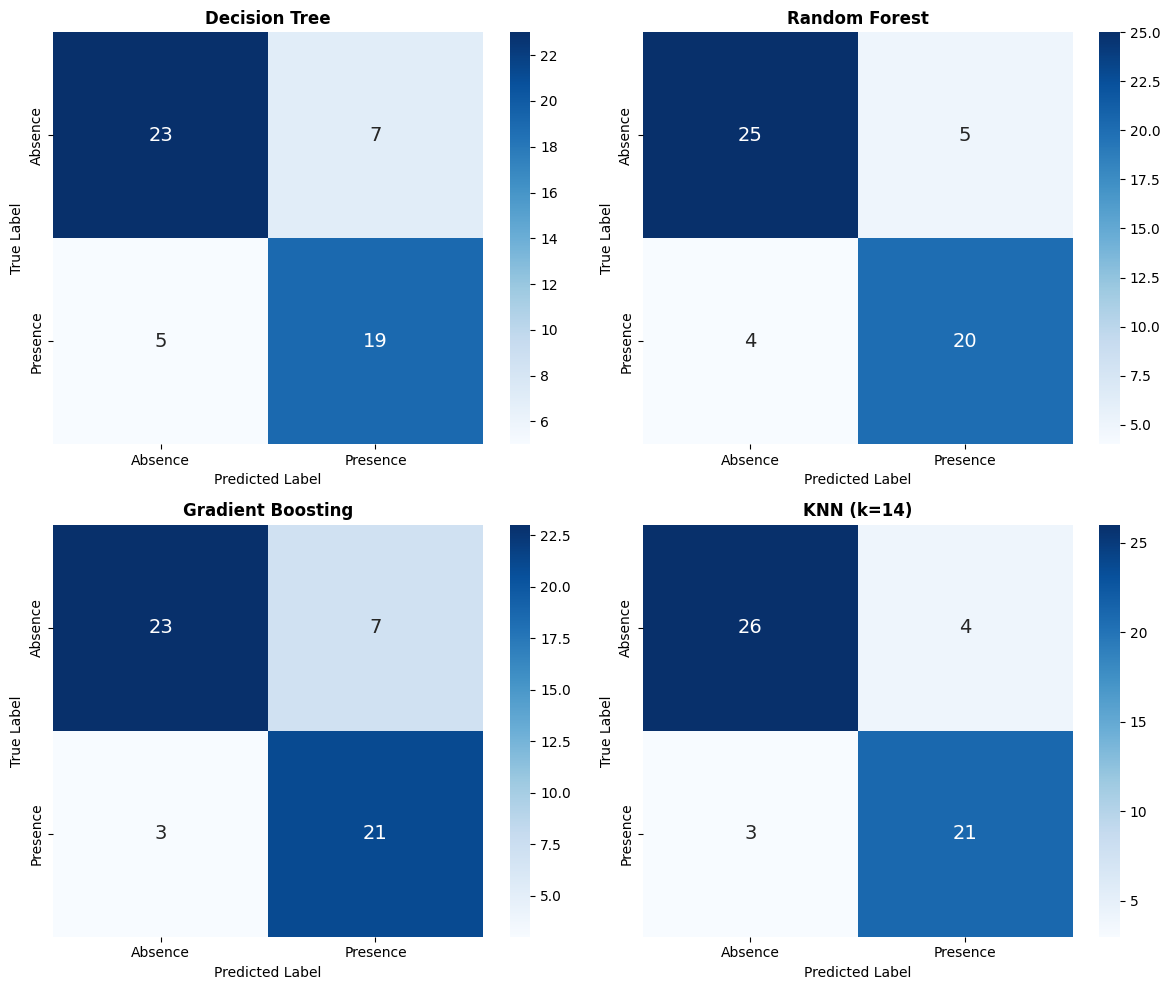

Plot saved as 'confusion_matrices.png'


In [26]:
print("\nGenerating Confusion Matrices...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_preds = [
    ('Decision Tree', dt_pred),
    ('Random Forest', rf_pred),
    ('Gradient Boosting', gb_pred),
    (f'KNN (k={optimal_k})', knn_final_pred)
]

for idx, (model_name, predictions) in enumerate(models_preds):
    cm = confusion_matrix(y_test, predictions)
    row = idx // 2
    col = idx % 2

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Absence', 'Presence'],
                yticklabels=['Absence', 'Presence'],
                ax=axes[row, col], cbar=True, annot_kws={'size': 14})
    axes[row, col].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('True Label', fontsize=10)
    axes[row, col].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'confusion_matrices.png'")

## Detailed Classification Reports

In [27]:
print("DETAILED CLASSIFICATION REPORTS")

print("\nDecision Tree:")
print(classification_report(y_test, dt_pred, target_names=['Absence', 'Presence']))

print("\nRandom Forest:")
print(classification_report(y_test, rf_pred, target_names=['Absence', 'Presence']))

print("\nGradient Boosting:")
print(classification_report(y_test, gb_pred, target_names=['Absence', 'Presence']))

print("\nKNN (k={}):" .format(optimal_k))
print(classification_report(y_test, knn_final_pred, target_names=['Absence', 'Presence']))

DETAILED CLASSIFICATION REPORTS

Decision Tree:
              precision    recall  f1-score   support

     Absence       0.82      0.77      0.79        30
    Presence       0.73      0.79      0.76        24

    accuracy                           0.78        54
   macro avg       0.78      0.78      0.78        54
weighted avg       0.78      0.78      0.78        54


Random Forest:
              precision    recall  f1-score   support

     Absence       0.86      0.83      0.85        30
    Presence       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54


Gradient Boosting:
              precision    recall  f1-score   support

     Absence       0.88      0.77      0.82        30
    Presence       0.75      0.88      0.81        24

    accuracy                           0.81        54
   macro avg       0.82      0.82      0.81 

## Final Summary

In [28]:
print("ANALYSIS COMPLETE!")
print("\n All models trained and evaluated")
print(" KNN optimal k-value identified:", optimal_k)
print(" Results presented in clear tables above")

ANALYSIS COMPLETE!

 All models trained and evaluated
 KNN optimal k-value identified: 14
 Results presented in clear tables above
